In [72]:
#Ölüm verilerinin incelenmesi 
death_coverage = df_countries.groupby('location').agg(
    toplam_satir=('total_deaths', 'size'),
    dolu_olum_kaydi=('total_deaths', 'count')
)

death_coverage['bos_olum_kaydi'] = (
    death_coverage['toplam_satir']
    - death_coverage['dolu_olum_kaydi']
)

print(
    death_coverage
    .sort_values('dolu_olum_kaydi')
    .head(15)
)


                 toplam_satir  dolu_olum_kaydi  bos_olum_kaydi
location                                                      
Macao                     795                0             795
Hong Kong                1654                0            1654
Taiwan                   1348                0            1348
Northern Cyprus           691                0             691
Western Sahara              1                0               1
Andorra                  1674             1674               0
Afghanistan              1674             1674               0
Albania                  1674             1674               0
Argentina                1678             1674               4
Armenia                  1674             1674               0
Aruba                    1674             1674               0
Australia                1674             1674               0
Austria                  1674             1674               0
Angola                   1674             1674         

In [73]:
#hem dolu hem boş ölüm kaydına sahip olanları inceliyoruz 
partial_death_missing = death_coverage[
    (death_coverage['dolu_olum_kaydi'] > 0)
    & (death_coverage['bos_olum_kaydi'] > 0)
]

print(
    partial_death_missing
    .sort_values('bos_olum_kaydi', ascending=False)
    .to_string()
)

             toplam_satir  dolu_olum_kaydi  bos_olum_kaydi
location                                                  
Malaysia             1684             1674              10
Lithuania            1684             1674              10
India                1682             1674               8
Czechia              1682             1674               8
Estonia              1682             1674               8
New Zealand          1681             1674               7
Argentina            1678             1674               4
Mexico               1678             1674               4
Italy                1677             1674               3
Thailand             1675             1674               1


In [74]:
#boş ölüm kayıtları hangi tarihlerde
missing_death_rows = df_countries.loc[
    df_countries['location'].isin(partial_death_missing.index)
    & df_countries['total_deaths'].isna(),
    ['location', 'date', 'total_deaths']
]

missing_death_summary = missing_death_rows.groupby('location').agg(
    ilk_bos_olum_tarihi=('date', 'min'),
    son_bos_olum_tarihi=('date', 'max'),
    bos_olum_kaydi_sayisi=('date', 'size')
)

print(missing_death_summary)

            ilk_bos_olum_tarihi son_bos_olum_tarihi  bos_olum_kaydi_sayisi
location                                                                  
Argentina            2020-01-01          2020-01-04                      4
Czechia              2024-08-05          2024-08-12                      8
Estonia              2024-08-05          2024-08-12                      8
India                2024-08-05          2024-08-12                      8
Italy                2024-08-05          2024-08-07                      3
Lithuania            2024-08-05          2024-08-14                     10
Malaysia             2024-08-05          2024-08-14                     10
Mexico               2020-01-01          2020-01-04                      4
New Zealand          2024-08-05          2024-08-11                      7
Thailand             2020-01-04          2020-01-04                      1


In [75]:
#kümülatif ölüm çizgisi kesintisiz ilerliyor mu diye incelemek için olmayan verilerin hangi tarihlerde olduğuna bakıyoruz
valid_death_range = (
    df_countries.loc[df_countries['total_deaths'].notna()]
    .groupby('location')
    .agg(
        ilk_dolu_olum_tarihi=('date', 'min'),
        son_dolu_olum_tarihi=('date', 'max')
    )
)

death_coverage_comparison = (
    missing_death_summary
    .join(valid_death_range)
)

print(death_coverage_comparison)

            ilk_bos_olum_tarihi son_bos_olum_tarihi  bos_olum_kaydi_sayisi  \
location                                                                     
Argentina            2020-01-01          2020-01-04                      4   
Czechia              2024-08-05          2024-08-12                      8   
Estonia              2024-08-05          2024-08-12                      8   
India                2024-08-05          2024-08-12                      8   
Italy                2024-08-05          2024-08-07                      3   
Lithuania            2024-08-05          2024-08-14                     10   
Malaysia             2024-08-05          2024-08-14                     10   
Mexico               2020-01-01          2020-01-04                      4   
New Zealand          2024-08-05          2024-08-11                      7   
Thailand             2020-01-04          2020-01-04                      1   

            ilk_dolu_olum_tarihi son_dolu_olum_tarihi  
locatio

In [76]:
#total deaths değerinin bir önceki güne göre negatif olduğu ülkeler
death_changes = df_countries[
    ['location', 'date', 'total_deaths']
].sort_values(['location', 'date']).copy()

death_changes['degisim'] = (
    death_changes.groupby('location')['total_deaths'].diff()
)

death_decreases = death_changes[
    death_changes['degisim'] < 0
]

print(death_decreases.to_string(index=False))

                       location       date  total_deaths  degisim
                      Australia 2023-07-23       22694.0    -76.0
Bonaire Sint Eustatius and Saba 2021-10-17          19.0     -1.0
                         Canada 2022-06-19       41017.0   -331.0
                          Chile 2023-04-02       61050.0  -3432.0
                          China 2024-01-14      121916.0    -22.0
                     Guadeloupe 2020-11-01         126.0     -1.0
                      Indonesia 2024-02-11      162050.0     -4.0
                         Panama 2023-05-07        8620.0     -1.0
               Papua New Guinea 2023-08-13         640.0    -30.0
                        Reunion 2020-08-30           3.0     -3.0
                   Sierra Leone 2022-06-12         125.0     -1.0
                       Thailand 2020-11-22           0.0    -60.0


In [77]:
#Değişimin negatif olduğu tarihlerde new_deaths değerinin girilmemesi
death_decrease_details = death_decreases.merge(
    df_countries[['location', 'date', 'new_deaths']],
    on=['location', 'date'],
    how='left',
    validate='one_to_one'
)

print(death_decrease_details.to_string(index=False))

                       location       date  total_deaths  degisim  new_deaths
                      Australia 2023-07-23       22694.0    -76.0         NaN
Bonaire Sint Eustatius and Saba 2021-10-17          19.0     -1.0         NaN
                         Canada 2022-06-19       41017.0   -331.0         NaN
                          Chile 2023-04-02       61050.0  -3432.0         NaN
                          China 2024-01-14      121916.0    -22.0         NaN
                     Guadeloupe 2020-11-01         126.0     -1.0         NaN
                      Indonesia 2024-02-11      162050.0     -4.0         NaN
                         Panama 2023-05-07        8620.0     -1.0         NaN
               Papua New Guinea 2023-08-13         640.0    -30.0         NaN
                        Reunion 2020-08-30           3.0     -3.0         NaN
                   Sierra Leone 2022-06-12         125.0     -1.0         NaN
                       Thailand 2020-11-22           0.0    -60.

In [78]:
#new deaths sütunun incelenmesi
new_death_coverage = df_countries.groupby('location').agg(
    toplam_satir=('new_deaths', 'size'),
    dolu_yeni_olum_kaydi=('new_deaths', 'count')
)

new_death_coverage['bos_yeni_olum_kaydi'] = (
    new_death_coverage['toplam_satir']
    - new_death_coverage['dolu_yeni_olum_kaydi']
)

print(
    new_death_coverage
    .sort_values('bos_yeni_olum_kaydi', ascending=False)
    .head(15)
)

                 toplam_satir  dolu_yeni_olum_kaydi  bos_yeni_olum_kaydi
location                                                                
Hong Kong                1654                     0                 1654
Taiwan                   1348                     0                 1348
Macao                     795                     0                  795
Northern Cyprus           691                     0                  691
France                   1674                  1274                  400
Spain                    1674                  1282                  392
Germany                  1674                  1282                  392
Lithuania                1684                  1674                   10
Malaysia                 1684                  1674                   10
Czechia                  1682                  1674                    8
India                    1682                  1674                    8
Estonia                  1682                  1674

In [79]:
partial_new_death_missing = new_death_coverage[
    (new_death_coverage['dolu_yeni_olum_kaydi'] > 0)
    & (new_death_coverage['bos_yeni_olum_kaydi'] > 0)
]

print(
    partial_new_death_missing
    .sort_values('bos_yeni_olum_kaydi', ascending=False)
    .to_string()
)

                                 toplam_satir  dolu_yeni_olum_kaydi  bos_yeni_olum_kaydi
location                                                                                
France                                   1674                  1274                  400
Germany                                  1674                  1282                  392
Spain                                    1674                  1282                  392
Lithuania                                1684                  1674                   10
Malaysia                                 1684                  1674                   10
Czechia                                  1682                  1674                    8
India                                    1682                  1674                    8
Estonia                                  1682                  1674                    8
New Zealand                              1681                  1674                    7
Argentina            

In [80]:
missing_new_death_rows = df_countries.loc[
    df_countries['location'].isin(partial_new_death_missing.index)
    & df_countries['new_deaths'].isna(),
    ['location', 'date', 'new_deaths']
]

missing_new_death_summary = missing_new_death_rows.groupby(
    'location'
).agg(
    ilk_bos_yeni_olum_tarihi=('date', 'min'),
    son_bos_yeni_olum_tarihi=('date', 'max'),
    bos_yeni_olum_kaydi_sayisi=('date', 'size')
)

print(missing_new_death_summary)

                                ilk_bos_yeni_olum_tarihi  \
location                                                   
Argentina                                     2020-01-01   
Australia                                     2023-07-23   
Bonaire Sint Eustatius and Saba               2021-10-17   
Canada                                        2022-06-19   
Chile                                         2023-04-02   
China                                         2024-01-14   
Czechia                                       2024-08-05   
Estonia                                       2024-08-05   
France                                        2023-07-02   
Germany                                       2023-07-10   
Guadeloupe                                    2020-11-01   
India                                         2024-08-05   
Indonesia                                     2024-02-11   
Italy                                         2024-08-05   
Lithuania                               

In [81]:
valid_new_death_range = (
    df_countries.loc[df_countries['new_deaths'].notna()]
    .groupby('location')
    .agg(
        ilk_dolu_yeni_olum_tarihi=('date', 'min'),
        son_dolu_yeni_olum_tarihi=('date', 'max')
    )
)

new_death_coverage_comparison = (
    missing_new_death_summary
    .join(valid_new_death_range)
)

print(new_death_coverage_comparison)

                                ilk_bos_yeni_olum_tarihi  \
location                                                   
Argentina                                     2020-01-01   
Australia                                     2023-07-23   
Bonaire Sint Eustatius and Saba               2021-10-17   
Canada                                        2022-06-19   
Chile                                         2023-04-02   
China                                         2024-01-14   
Czechia                                       2024-08-05   
Estonia                                       2024-08-05   
France                                        2023-07-02   
Germany                                       2023-07-10   
Guadeloupe                                    2020-11-01   
India                                         2024-08-05   
Indonesia                                     2024-02-11   
Italy                                         2024-08-05   
Lithuania                               

In [82]:
#aradaki boş günleri doğrudan görmek için
missing_new_death_with_range = (
    missing_new_death_rows
    .merge(
        valid_new_death_range,
        on='location',
        how='left',
        validate='many_to_one'
    )
)

interior_missing_new_deaths = missing_new_death_with_range.loc[
    missing_new_death_with_range['date'].between(
        missing_new_death_with_range['ilk_dolu_yeni_olum_tarihi'],
        missing_new_death_with_range['son_dolu_yeni_olum_tarihi']
    ),
    ['location', 'date', 'new_deaths']
].sort_values(['location', 'date'])

print(interior_missing_new_deaths.to_string(index=False))

                       location       date  new_deaths
                      Australia 2023-07-23         NaN
Bonaire Sint Eustatius and Saba 2021-10-17         NaN
                         Canada 2022-06-19         NaN
                          Chile 2023-04-02         NaN
                          China 2024-01-14         NaN
                     Guadeloupe 2020-11-01         NaN
                      Indonesia 2024-02-11         NaN
                         Panama 2023-05-07         NaN
               Papua New Guinea 2023-08-13         NaN
                        Reunion 2020-08-30         NaN
                   Sierra Leone 2022-06-12         NaN
                       Thailand 2020-11-22         NaN


      date  new_deaths  total_deaths
2022-06-13         0.0       41348.0
2022-06-14         0.0       41348.0
2022-06-15         0.0       41348.0
2022-06-16         0.0       41348.0
2022-06-17         0.0       41348.0
2022-06-18         0.0       41348.0
2022-06-19         NaN       41017.0


C:\Users\nazlican\AppData\Local\Temp\ipykernel_10932\442493259.py:38: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  canada_weekly_deaths_example['date'].min() - pd.Timedelta(days=0.5),
C:\Users\nazlican\AppData\Local\Temp\ipykernel_10932\442493259.py:39: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  canada_weekly_deaths_example['date'].max() + pd.Timedelta(days=0.5)


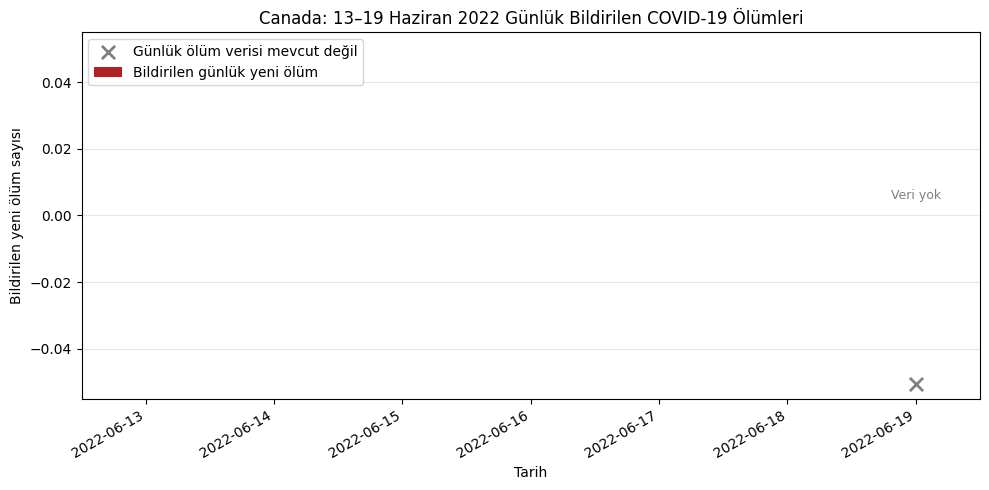

In [83]:
#kanada için ölüm kayıtları 19 haziran 2022 tarihi
canada_weekly_deaths_example = df_countries.loc[
    (df_countries['location'] == 'Canada')
    & df_countries['date'].between('2022-06-13', '2022-06-19'),
    ['date', 'new_deaths', 'total_deaths']
].sort_values('date').copy()

print(canada_weekly_deaths_example.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))

# Dolu günlük ölüm değerlerini çubuk olarak çiz.
ax.bar(
    canada_weekly_deaths_example['date'],
    canada_weekly_deaths_example['new_deaths'],
    width=0.8,
    color='firebrick',
    label='Bildirilen günlük yeni ölüm'
)

# new_deaths değeri boş olan günü bul.
missing_day = canada_weekly_deaths_example['new_deaths'].isna()

# Boş günü sıfır ölüm gibi göstermeden, grafiğin altına X işareti koy.
ax.scatter(
    canada_weekly_deaths_example.loc[missing_day, 'date'],
    [0.04] * missing_day.sum(),
    transform=ax.get_xaxis_transform(),
    marker='x',
    s=90,
    linewidths=2,
    color='gray',
    label='Günlük ölüm verisi mevcut değil',
    zorder=3
)

ax.set_xlim(
    canada_weekly_deaths_example['date'].min() - pd.Timedelta(days=0.5),
    canada_weekly_deaths_example['date'].max() + pd.Timedelta(days=0.5)
)

ax.set_xticks(canada_weekly_deaths_example['date'])

ax.annotate(
    'Veri yok',
    xy=(pd.Timestamp('2022-06-19'), 0),
    xytext=(0, 12),
    textcoords='offset points',
    ha='center',
    color='gray',
    fontsize=9
)

ax.set_title('Canada: 13–19 Haziran 2022 Günlük Bildirilen COVID-19 Ölümleri')
ax.set_xlabel('Tarih')
ax.set_ylabel('Bildirilen yeni ölüm sayısı')
ax.grid(axis='y', alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [84]:
daily_deaths = df_countries[
    ['location', 'date', 'new_deaths']
].copy()

daily_deaths['hafta_baslangici'] = (
    daily_deaths['date']
    - pd.to_timedelta(
        daily_deaths['date'].dt.dayofweek,
        unit='D'
    )
)

weekly_deaths_preview = (
    daily_deaths
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        mevcut_olum_toplami=(
            'new_deaths',
            lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'nunique'),
        dolu_gun=('new_deaths', 'count')
    )
    .reset_index()
)

six_of_seven_positive_weeks = weekly_deaths_preview.loc[
    (weekly_deaths_preview['dolu_gun'] == 6)
    & (weekly_deaths_preview['mevcut_olum_toplami'] > 0),
    ['location', 'hafta_baslangici',
     'mevcut_olum_toplami', 'kayitli_gun', 'dolu_gun']
].sort_values('mevcut_olum_toplami', ascending=False)

print(six_of_seven_positive_weeks.to_string(index=False))

Empty DataFrame
Columns: [location, hafta_baslangici, mevcut_olum_toplami, kayitli_gun, dolu_gun]
Index: []


In [85]:
incomplete_positive_death_weeks = weekly_deaths_preview.loc[
    weekly_deaths_preview['dolu_gun'].between(1, 6)
    & (weekly_deaths_preview['mevcut_olum_toplami'] > 0),
    ['location', 'hafta_baslangici',
     'mevcut_olum_toplami', 'kayitli_gun', 'dolu_gun']
].sort_values('mevcut_olum_toplami', ascending=False)

print(incomplete_positive_death_weeks.to_string(index=False))

location hafta_baslangici  mevcut_olum_toplami  kayitli_gun  dolu_gun
 Germany       2019-12-30                  3.0            1         1


In [86]:
turkey_full_death_weeks = (
    weekly_deaths_preview.loc[
        (weekly_deaths_preview['location'] == 'Turkey')
        & (weekly_deaths_preview['dolu_gun'] == 7)
    ]
    .sort_values('mevcut_olum_toplami', ascending=False)
)

print(
    turkey_full_death_weeks[
        ['hafta_baslangici', 'mevcut_olum_toplami',
         'kayitli_gun', 'dolu_gun']
    ].head(5).to_string(index=False)
)

hafta_baslangici  mevcut_olum_toplami  kayitli_gun  dolu_gun
      2021-04-26               2493.0            7         7
      2021-04-19               2403.0            7         7
      2021-05-03               2242.0            7         7
      2022-02-14               1916.0            7         7
      2021-04-12               1906.0            7         7


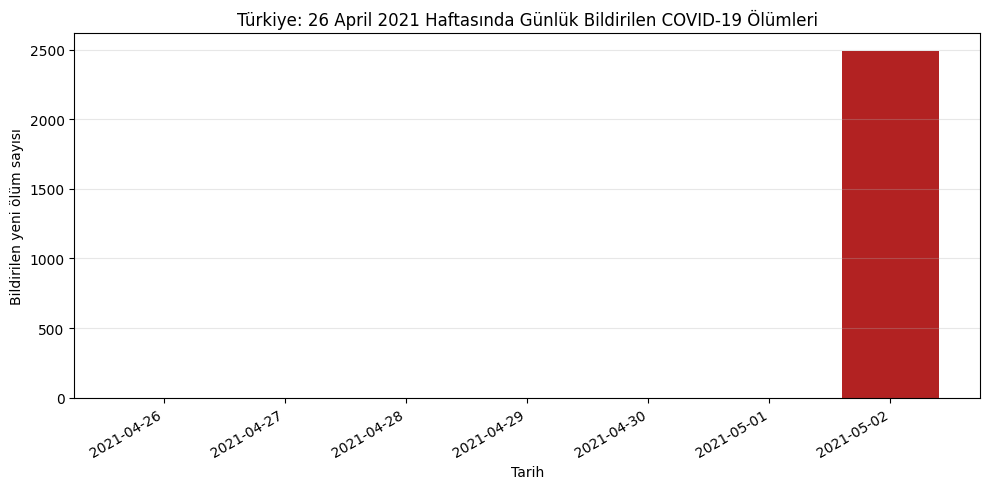

In [87]:
selected_death_week = turkey_full_death_weeks.iloc[0]

selected_week_start = selected_death_week['hafta_baslangici']

turkey_daily_death_example = daily_deaths.loc[
    (daily_deaths['location'] == 'Turkey')
    & (daily_deaths['hafta_baslangici'] == selected_week_start),
    ['date', 'new_deaths']
].sort_values('date')

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    turkey_daily_death_example['date'],
    turkey_daily_death_example['new_deaths'],
    width=0.8,
    color='firebrick'
)

ax.set_xticks(turkey_daily_death_example['date'])
ax.set_title(
    f"Türkiye: {selected_week_start:%d %B %Y} Haftasında "
    "Günlük Bildirilen COVID-19 Ölümleri"
)
ax.set_xlabel('Tarih')
ax.set_ylabel('Bildirilen yeni ölüm sayısı')
ax.grid(axis='y', alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [88]:
weekly_deaths = (
    daily_deaths
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        mevcut_olum_toplami=(
            'new_deaths',
            lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'nunique'),
        dolu_gun=('new_deaths', 'count')
    )
    .reset_index()
)

weekly_deaths['eksik_gun'] = 7 - weekly_deaths['dolu_gun']

weekly_deaths['tam_hafta'] = (
    weekly_deaths['dolu_gun'] == 7
)

weekly_deaths['haftalik_yeni_olum'] = (
    weekly_deaths['mevcut_olum_toplami']
    .where(weekly_deaths['tam_hafta'])
)

print(weekly_deaths.head(10).to_string(index=False))

   location hafta_baslangici  mevcut_olum_toplami  kayitli_gun  dolu_gun  eksik_gun  tam_hafta  haftalik_yeni_olum
Afghanistan       2019-12-30                  0.0            1         1          6      False                 NaN
Afghanistan       2020-01-06                  0.0            7         7          0       True                 0.0
Afghanistan       2020-01-13                  0.0            7         7          0       True                 0.0
Afghanistan       2020-01-20                  0.0            7         7          0       True                 0.0
Afghanistan       2020-01-27                  0.0            7         7          0       True                 0.0
Afghanistan       2020-02-03                  0.0            7         7          0       True                 0.0
Afghanistan       2020-02-10                  0.0            7         7          0       True                 0.0
Afghanistan       2020-02-17                  0.0            7         7        

In [89]:
weekly_deaths = weekly_deaths.sort_values(
    ['location', 'hafta_baslangici']
).copy()

weekly_deaths['onceki_hafta_olum'] = (
    weekly_deaths.groupby('location')['haftalik_yeni_olum']
    .shift(1)
)

weekly_deaths['haftalik_olum_degisim'] = (
    weekly_deaths['haftalik_yeni_olum']
    - weekly_deaths['onceki_hafta_olum']
)

weekly_deaths['haftalik_olum_degisim_yuzde'] = (
    weekly_deaths['haftalik_olum_degisim']
    .div(
        weekly_deaths['onceki_hafta_olum'].where(
            weekly_deaths['onceki_hafta_olum'] > 0
        )
    )
    .mul(100)
)

In [90]:
selected_country = 'United States'

us_weekly_deaths = weekly_deaths.loc[
    (weekly_deaths['location'] == selected_country)
    & weekly_deaths['hafta_baslangici'].between(
        '2021-01-04', '2021-02-01'
    ),
    ['hafta_baslangici', 'dolu_gun',
     'haftalik_yeni_olum', 'onceki_hafta_olum',
     'haftalik_olum_degisim',
     'haftalik_olum_degisim_yuzde']
].sort_values('hafta_baslangici')

print(us_weekly_deaths.to_string(index=False))

hafta_baslangici  dolu_gun  haftalik_yeni_olum  onceki_hafta_olum  haftalik_olum_degisim  haftalik_olum_degisim_yuzde
      2021-01-04         7             21497.0            19650.0                 1847.0                     9.399491
      2021-01-11         7             23312.0            21497.0                 1815.0                     8.443039
      2021-01-18         7             22495.0            23312.0                 -817.0                    -3.504633
      2021-01-25         7             22249.0            22495.0                 -246.0                    -1.093576
      2021-02-01         7             20100.0            22249.0                -2149.0                    -9.658861


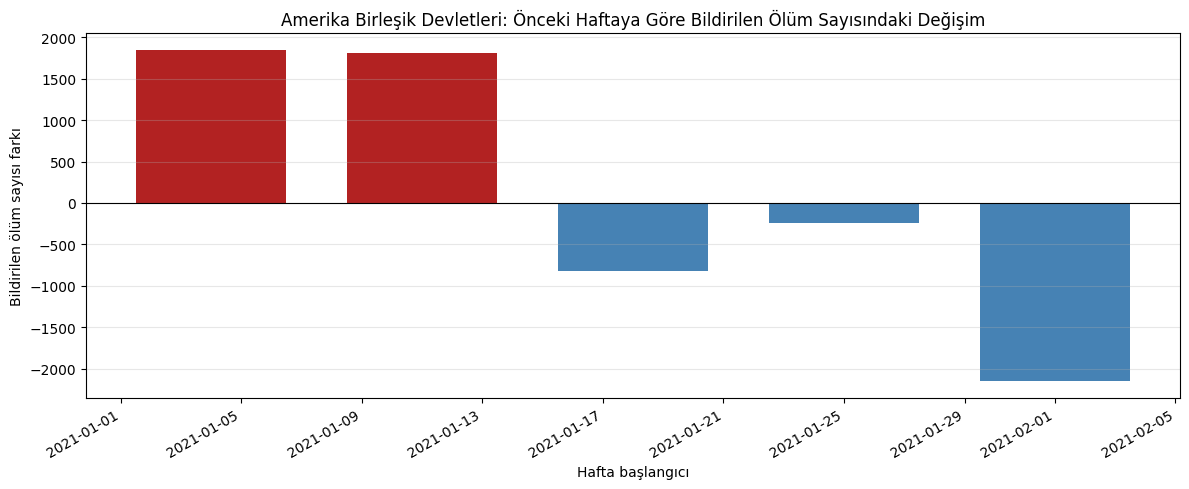

In [91]:
plot_deaths = us_weekly_deaths.copy()

colors = np.where(
    plot_deaths['haftalik_olum_degisim'] >= 0,
    'firebrick',
    'steelblue'
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    plot_deaths['hafta_baslangici'],
    plot_deaths['haftalik_olum_degisim'],
    color=colors,
    width=5
)

ax.axhline(0, color='black', linewidth=0.8)

ax.set_title(
    'Amerika Birleşik Devletleri: Önceki Haftaya Göre '
    'Bildirilen Ölüm Sayısındaki Değişim'
)
ax.set_xlabel('Hafta başlangıcı')
ax.set_ylabel('Bildirilen ölüm sayısı farkı')
ax.grid(axis='y', alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [92]:
population_by_location = (
    df_countries
    .groupby('location')['population']
    .first()
)

weekly_deaths['population'] = (
    weekly_deaths['location']
    .map(population_by_location)
)

weekly_deaths['haftalik_olum_milyon_basina'] = (
    weekly_deaths['haftalik_yeni_olum']
    / weekly_deaths['population']
    * 1_000_000
)

print(
    weekly_deaths[
        ['location', 'hafta_baslangici',
         'haftalik_yeni_olum', 'population',
         'haftalik_olum_milyon_basina']
    ].head(10).to_string(index=False)
)

   location hafta_baslangici  haftalik_yeni_olum  population  haftalik_olum_milyon_basina
Afghanistan       2019-12-30                 NaN    41128772                          NaN
Afghanistan       2020-01-06                 0.0    41128772                          0.0
Afghanistan       2020-01-13                 0.0    41128772                          0.0
Afghanistan       2020-01-20                 0.0    41128772                          0.0
Afghanistan       2020-01-27                 0.0    41128772                          0.0
Afghanistan       2020-02-03                 0.0    41128772                          0.0
Afghanistan       2020-02-10                 0.0    41128772                          0.0
Afghanistan       2020-02-17                 0.0    41128772                          0.0
Afghanistan       2020-02-24                 0.0    41128772                          0.0
Afghanistan       2020-03-02                 0.0    41128772                          0.0


In [93]:
selected_week = pd.Timestamp('2021-01-04')

week_death_per_million = weekly_deaths.loc[
    (weekly_deaths['hafta_baslangici'] == selected_week)
    & weekly_deaths['tam_hafta'],
    ['location', 'haftalik_yeni_olum',
     'population', 'haftalik_olum_milyon_basina']
].sort_values('haftalik_olum_milyon_basina', ascending=False)

print(week_death_per_million.head(15).to_string(index=False))

      location  haftalik_yeni_olum  population  haftalik_olum_milyon_basina
     Gibraltar                 5.0       32677                   153.012822
 Liechtenstein                 6.0       39355                   152.458392
        Jersey                13.0      110796                   117.332756
       Czechia              1187.0    10493990                   113.112362
      Slovakia               601.0     5643455                   106.495046
        Latvia               189.0     1850654                   102.126059
United Kingdom              6625.0    67508936                    98.135157
     Lithuania               269.0     2750058                    97.816119
      Slovenia               201.0     2119843                    94.818343
    San Marino                 3.0       33690                    89.047195
       Croatia               326.0     4030361                    80.886055
       Hungary               764.0     9967304                    76.650617
      Portug

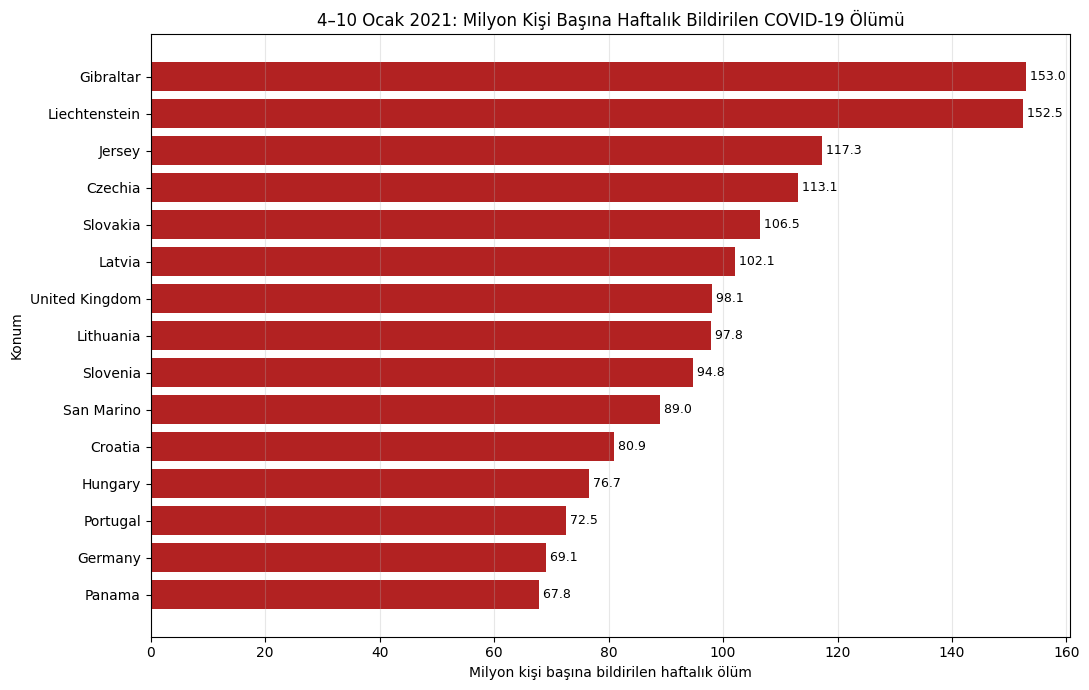

In [94]:
plot_death_per_million = (
    week_death_per_million
    .head(15)
    .sort_values('haftalik_olum_milyon_basina')
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    plot_death_per_million['location'],
    plot_death_per_million['haftalik_olum_milyon_basina'],
    color='firebrick'
)

ax.set_title(
    '4–10 Ocak 2021: Milyon Kişi Başına Haftalık Bildirilen COVID-19 Ölümü'
)
ax.set_xlabel('Milyon kişi başına bildirilen haftalık ölüm')
ax.set_ylabel('Konum')
ax.grid(axis='x', alpha=0.3)

for i, value in enumerate(
    plot_death_per_million['haftalik_olum_milyon_basina']
):
    ax.text(
        value,
        i,
        f' {value:,.1f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [186]:
excess_mortality_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_fazla_olum_kaydi=(
            'excess_mortality',
            'count'
        ),
        dolu_kumulatif_fazla_olum_kaydi=(
            'excess_mortality_cumulative_per_million',
            'count'
        )
    )
)

excess_mortality_coverage['bos_fazla_olum_kaydi'] = (
    excess_mortality_coverage['toplam_satir']
    - excess_mortality_coverage['dolu_fazla_olum_kaydi']
)

print(
    excess_mortality_coverage
    .sort_values(
        'dolu_kumulatif_fazla_olum_kaydi',
        ascending=False
    )
    .head(20)
)

               toplam_satir  dolu_fazla_olum_kaydi  \
location                                             
Austria                1674                    209   
Australia              1674                    209   
Belgium                1674                    209   
Bulgaria               1674                    209   
Canada                 1674                    209   
Chile                  1674                    209   
Finland                1674                    209   
Estonia                1682                    209   
French Guiana          1674                    209   
France                 1674                    209   
Ecuador                1674                    209   
Denmark                1674                    209   
Czechia                1682                    209   
Cyprus                 1674                    209   
Croatia                1674                    209   
Greece                 1674                    209   
Guadeloupe             1674 

In [187]:
italy_excess_data = (
    df_countries[
        df_countries['location'] == 'Italy'
    ][
        [
            'date',
            'excess_mortality',
            'excess_mortality_cumulative_per_million',
            'total_deaths_per_million'
        ]
    ]
    .dropna(
        subset=['excess_mortality_cumulative_per_million']
    )
    .sort_values('date')
    .copy()
)

italy_excess_data['kayitlar_arasi_gun'] = (
    italy_excess_data['date']
    .diff()
    .dt.days
)

print('İlk fazla ölüm kaydı:', italy_excess_data['date'].min())
print('Son fazla ölüm kaydı:', italy_excess_data['date'].max())
print('Kayıt sayısı:', len(italy_excess_data))

print(
    italy_excess_data['kayitlar_arasi_gun']
    .value_counts()
    .sort_index()
)

İlk fazla ölüm kaydı: 2020-01-05 00:00:00
Son fazla ölüm kaydı: 2023-12-31 00:00:00
Kayıt sayısı: 209
kayitlar_arasi_gun
7.0    208
Name: count, dtype: int64


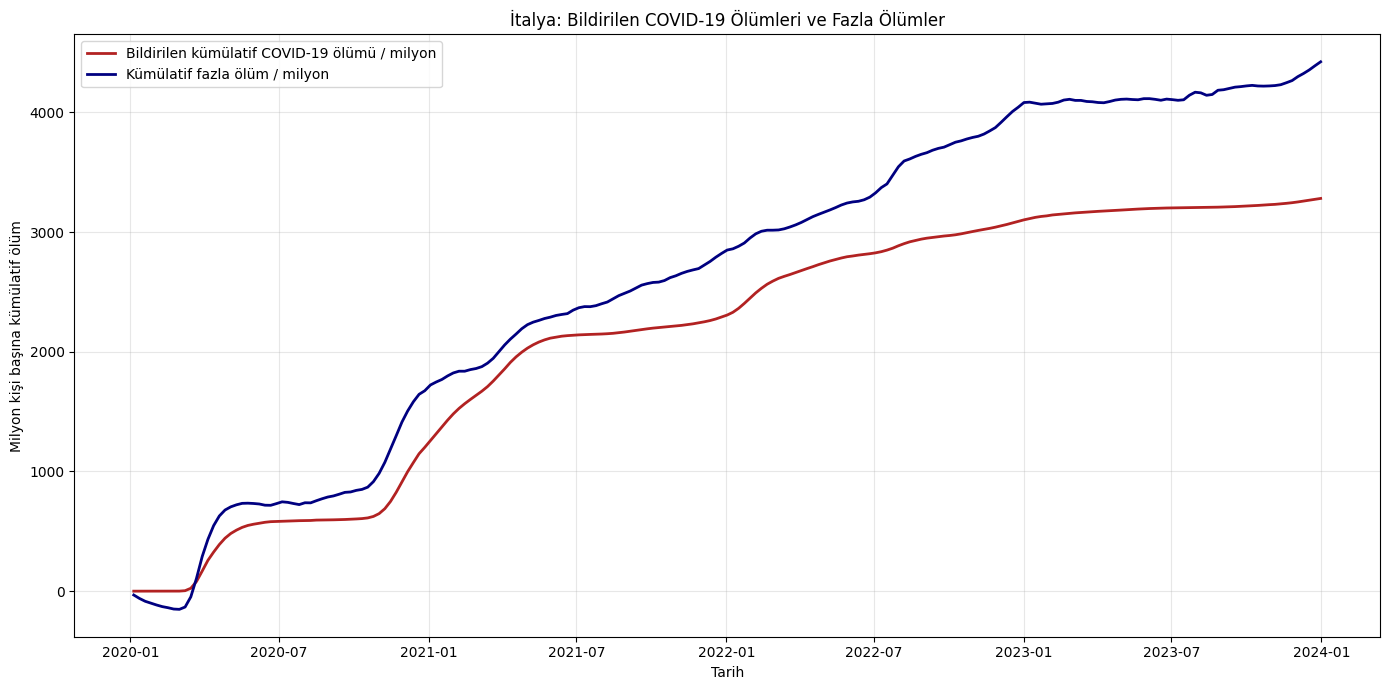

In [188]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    italy_excess_data['date'],
    italy_excess_data['total_deaths_per_million'],
    color='firebrick',
    linewidth=2,
    label='Bildirilen kümülatif COVID-19 ölümü / milyon'
)

ax.plot(
    italy_excess_data['date'],
    italy_excess_data['excess_mortality_cumulative_per_million'],
    color='navy',
    linewidth=2,
    label='Kümülatif fazla ölüm / milyon'
)

ax.set_title(
    'İtalya: Bildirilen COVID-19 Ölümleri ve Fazla Ölümler'
)
ax.set_xlabel('Tarih')
ax.set_ylabel('Milyon kişi başına kümülatif ölüm')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [189]:
italy_last_excess_record = italy_excess_data.iloc[-1]

death_gap_per_million = (
    italy_last_excess_record['excess_mortality_cumulative_per_million']
    - italy_last_excess_record['total_deaths_per_million']
)

print('Karşılaştırma tarihi:', italy_last_excess_record['date'].date())
print(
    'Bildirilen COVID-19 ölümü / milyon:',
    round(italy_last_excess_record['total_deaths_per_million'], 1)
)
print(
    'Kümülatif fazla ölüm / milyon:',
    round(
        italy_last_excess_record[
            'excess_mortality_cumulative_per_million'
        ],
        1
    )
)
print(
    'Aradaki fark / milyon:',
    round(death_gap_per_million, 1)
)

Karşılaştırma tarihi: 2023-12-31
Bildirilen COVID-19 ölümü / milyon: 3280.5
Kümülatif fazla ölüm / milyon: 4422.0
Aradaki fark / milyon: 1141.5


In [190]:
excess_date_coverage = (
    df_countries[
        df_countries[
            'excess_mortality_cumulative_per_million'
        ].notna()
    ]
    .groupby('date')['location']
    .nunique()
    .sort_values(ascending=False)
)

print(excess_date_coverage.head(10))

date
2020-05-31    125
2021-02-28    124
2021-01-31    124
2021-10-31    123
2022-07-31    105
2023-04-30     87
2023-12-31     74
2020-07-31     73
2020-03-31     73
2020-06-30     73
Name: location, dtype: int64


In [191]:
excess_comparison_date = pd.Timestamp('2023-12-31')

cross_country_excess_data = (
    df_countries[
        df_countries['date'] == excess_comparison_date
    ][
        [
            'location',
            'total_deaths_per_million',
            'excess_mortality_cumulative_per_million'
        ]
    ]
    .dropna()
    .copy()
)

print(
    'Karşılaştırılan ülke sayısı:',
    len(cross_country_excess_data)
)
print(cross_country_excess_data.head())

Karşılaştırılan ülke sayısı: 73
        location  total_deaths_per_million  \
3130     Albania                   1274.57   
4804     Algeria                    151.31   
16526    Armenia                   3045.94   
19874  Australia                    929.12   
21548    Austria                   2485.91   

       excess_mortality_cumulative_per_million  
3130                                   5040.67  
4804                                   2765.35  
16526                                  8289.06  
19874                                  1386.02  
21548                                  3178.02  


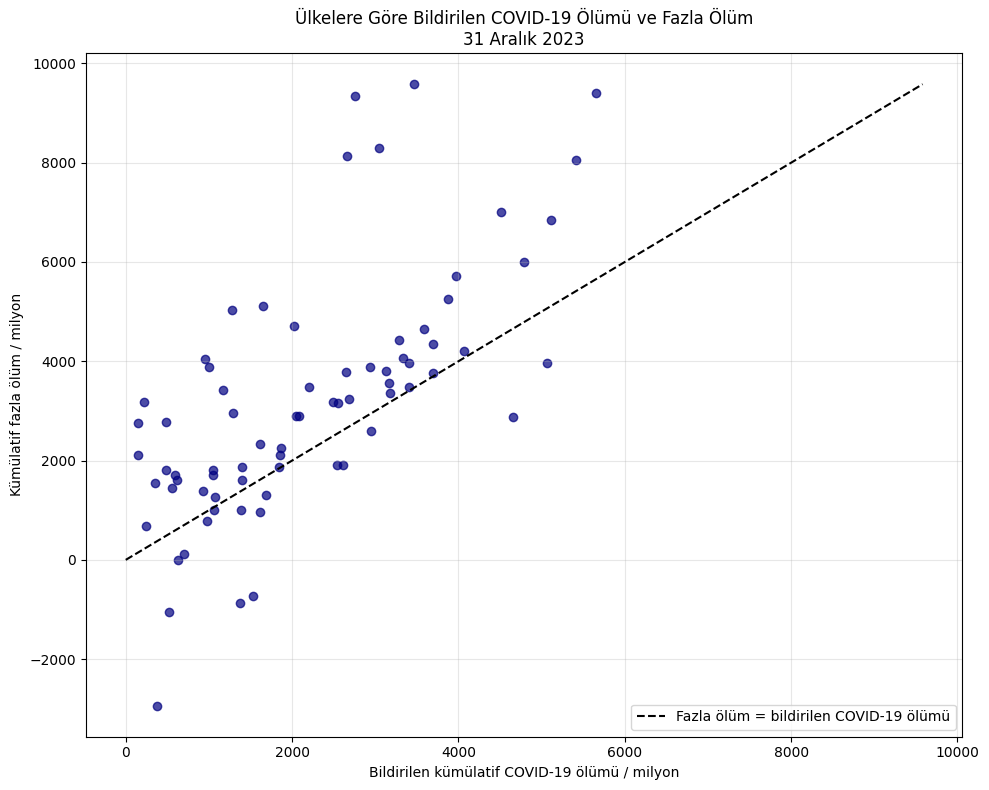

In [192]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    cross_country_excess_data['total_deaths_per_million'],
    cross_country_excess_data[
        'excess_mortality_cumulative_per_million'
    ],
    color='navy',
    alpha=0.7
)

max_value = max(
    cross_country_excess_data['total_deaths_per_million'].max(),
    cross_country_excess_data[
        'excess_mortality_cumulative_per_million'
    ].max()
)

ax.plot(
    [0, max_value],
    [0, max_value],
    color='black',
    linestyle='--',
    label='Fazla ölüm = bildirilen COVID-19 ölümü'
)

ax.set_title(
    'Ülkelere Göre Bildirilen COVID-19 Ölümü ve Fazla Ölüm\n'
    '31 Aralık 2023'
)
ax.set_xlabel('Bildirilen kümülatif COVID-19 ölümü / milyon')
ax.set_ylabel('Kümülatif fazla ölüm / milyon')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [193]:
cross_country_excess_data['olum_farki_per_million'] = (
    cross_country_excess_data[
        'excess_mortality_cumulative_per_million'
    ]
    - cross_country_excess_data['total_deaths_per_million']
)

print(
    'Fazla ölüm bildirilen COVID ölümünden yüksek ülke sayısı:',
    (
        cross_country_excess_data['olum_farki_per_million']
        .gt(0)
        .sum()
    )
)

print(
    'Fazla ölüm bildirilen COVID ölümünden düşük ülke sayısı:',
    (
        cross_country_excess_data['olum_farki_per_million']
        .lt(0)
        .sum()
    )
)

print('\nEn büyük pozitif farklar:')

print(
    cross_country_excess_data[
        [
            'location',
            'total_deaths_per_million',
            'excess_mortality_cumulative_per_million',
            'olum_farki_per_million'
        ]
    ]
    .sort_values('olum_farki_per_million', ascending=False)
    .head(10)
    .to_string(index=False)
)

Fazla ölüm bildirilen COVID ölümünden yüksek ülke sayısı: 57
Fazla ölüm bildirilen COVID ölümünden düşük ülke sayısı: 16

En büyük pozitif farklar:
    location  total_deaths_per_million  excess_mortality_cumulative_per_million  olum_farki_per_million
      Russia                   2756.97                                  9344.61                 6587.64
   Lithuania                   3469.39                                  9580.70                 6111.31
      Serbia                   2658.88                                  8130.29                 5471.41
     Armenia                   3045.94                                  8289.06                 5243.12
     Albania                   1274.57                                  5040.67                 3766.10
    Bulgaria                   5659.36                                  9407.14                 3747.78
South Africa                   1644.72                                  5115.79                 3471.07
  Kazakhstan        